In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
cluster_names = {
    0: 'Premium Customers',
    1: 'Budget Customers',
    2: 'Potential Customers',
    3: 'Moderate Customers',
    4: 'Low Engagement Customers'
}
df['Customer Segment'] = df['Cluster'].map(cluster_names)
print(df[['Cluster', 'Customer Segment']].head())

   Cluster          Customer Segment
0        4  Low Engagement Customers
1        2       Potential Customers
2        4  Low Engagement Customers
3        2       Potential Customers
4        4  Low Engagement Customers


In [31]:
import os
print(os.listdir('/content'))

['.config', 'Mall_Customers.csv', 'sample_data']


In [32]:
import pandas as pd

df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [33]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

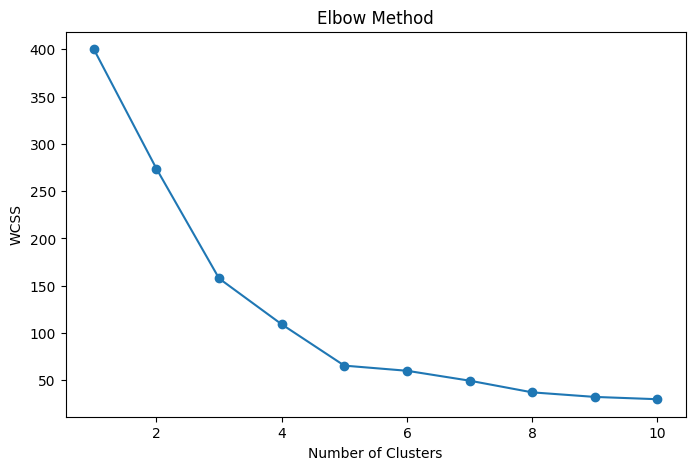

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

# Business Insights

• Premium Customers generate high revenue and should receive loyalty rewards.

• High Income Low Spenders represent an opportunity for targeted marketing campaigns.

• Low Engagement Customers contribute less revenue and may require low-cost engagement strategies.

• Potential Customers show high spending despite lower income and may respond well to discounts and offers.

In [38]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

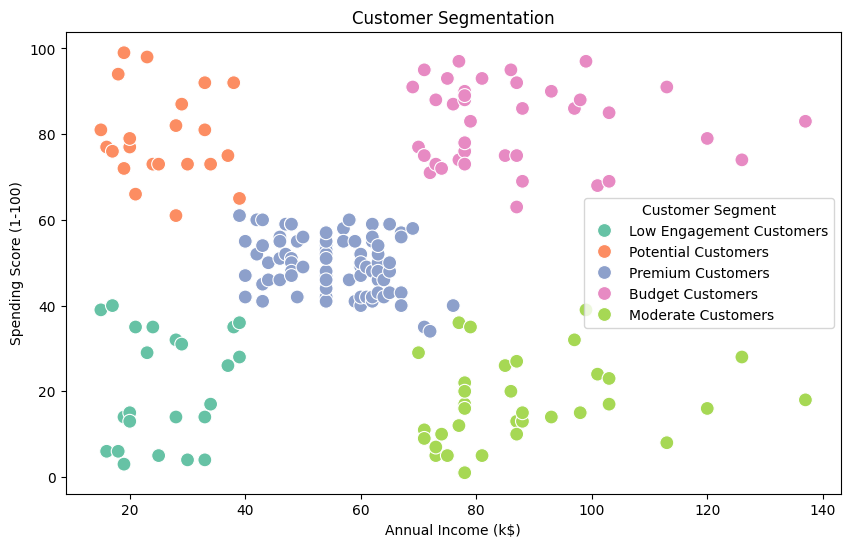

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Customer Segment',
    palette='Set2',
    s=100
)

plt.title('Customer Segmentation')

plt.show()

In [44]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)


         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [43]:
print(df[['Cluster', 'Customer Segment']].head())

   Cluster          Customer Segment
0        4  Low Engagement Customers
1        2       Potential Customers
2        4  Low Engagement Customers
3        2       Potential Customers
4        4  Low Engagement Customers


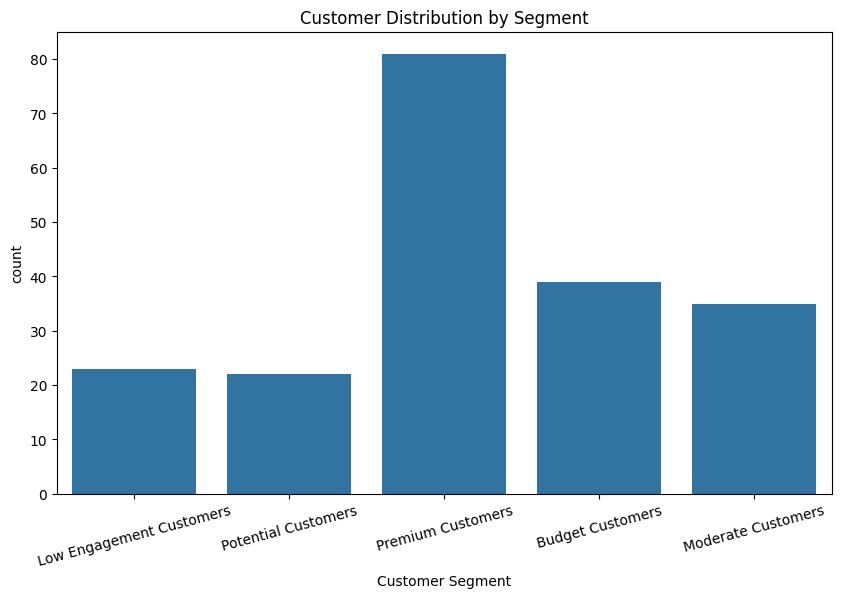

In [47]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Customer Segment',
    data=df
)

plt.xticks(rotation=15)

plt.title('Customer Distribution by Segment')

plt.show()